# Конвертация классификационной сети в полносвёрточную (FCN)
В этом уроке мы будем решать задачу локализации с помощью полносвёрточной нейронной сети (FCN). Многие этапы будут такими же, как и в практическом уроке про скользящее окно (всё, что касается построения и обучения классификатора).

Однако, здесь мы не будем применять классификатор в режиме скользящего окна. В этому уроке мы сконвертируем обученный классификатор в FCN и применим полученную FCN для решения задачи локализации (построение тепловых карт) за один проход.

### Загрузка необходимых библиотек
Здесь мы загружаем различные библиотеки, включая TensoFlow.


In [1]:
import random
import imageio
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

import tensorflow as tf
#tf.enable_eager_execution()
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


# Подготовка датасета

### Загрузка оригинального датасета MNIST
Загружаем датасет MNIST (train и test) и приводим данные к удобному формату:
* Размер: (N, 28, 28, 1), где N - количество образцов в подвыборке
* Значения интесивности: float32 в диапазоне [0, 1]

In [2]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()

train_x = train_x.reshape(-1, 28, 28, 1).astype(np.float32) / 255.
test_x = test_x.reshape(-1, 28, 28, 1).astype(np.float32) / 255.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Визуализация нескольких образцов из MNIST
Визуализируем несколько образцов из оригинального датасета MNIST

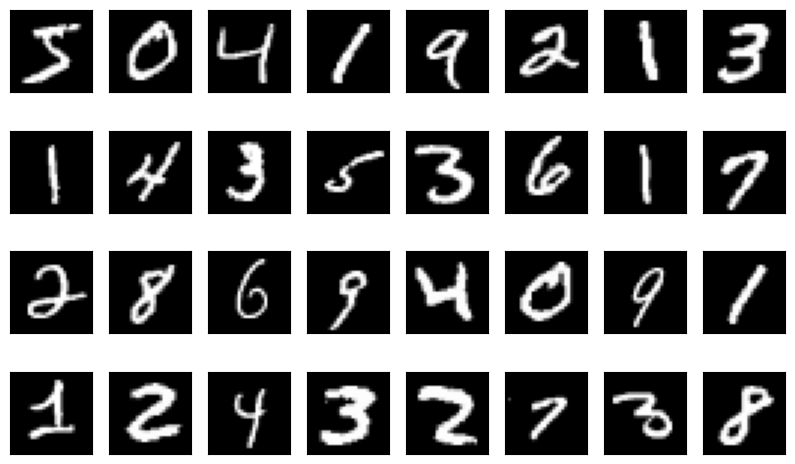

In [3]:
def plot_some_samples(some_samples):
    fig = plt.figure(figsize=(10, 6))
    for j in range(some_samples.shape[0]):
        ax = fig.add_subplot(4, 8, j+1)
        ax.imshow(some_samples[j,:,:,0], cmap='gray')
        plt.xticks([]), plt.yticks([])
    plt.show()

plot_some_samples(train_x[:32, ...])

### Аугментация: добавление образцов класса "фон"
Так же, как и раньше, нам понадобятся дополнительные образцы из класса "фон". Сгенерируем их тем же способом, что и раньше.

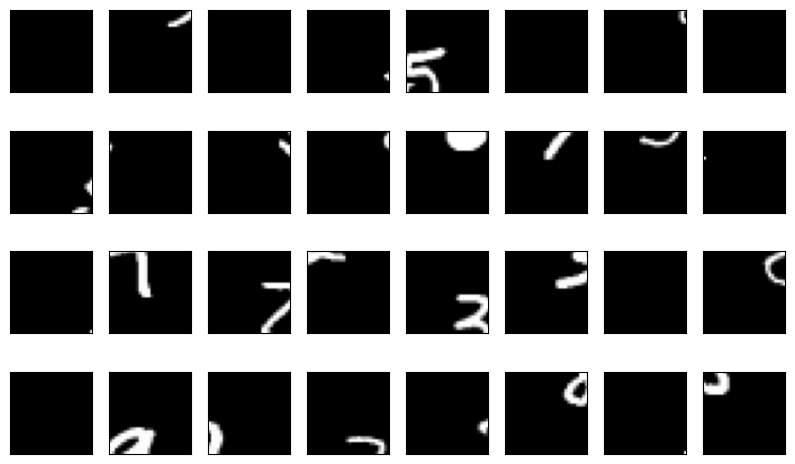

In [4]:
bg_samples = 100000 # Количество обучающих образцов из класса "фон"

bg_train_x = np.zeros((bg_samples, 28, 28, 1), dtype=np.float32)
bg_train_y = np.ones((bg_samples,), dtype=np.int32)*10

src_idxs = random.choices(range(train_x.shape[0]), k=bg_samples)

sh = train_x.shape[1]
sw = train_x.shape[2]
for i in range(bg_samples):
    dh = random.randint(sh//4, 3*sh//4) * random.choice([-1, 1])
    dw = random.randint(sw//4, 3*sw//4) * random.choice([-1, 1])

    sample = train_x[src_idxs[i], ...]

    bg_train_x[i, max(-dh,0):min(sh-dh,sh), max(-dw,0):min(sw-dw, sw), :] = \
        sample[max( dh,0):min(sh+dh,sh), max( dw,0):min(sw+dw, sw), :]

plot_some_samples(bg_train_x[:32, ...])

### Аугментация: добавление образцов исходных классов цифр
Так же, как и раньше, нам понадобятся дополнительные образцы цифр с небольшими смещениями. Сгенерируем их тем же способом, что и раньше.

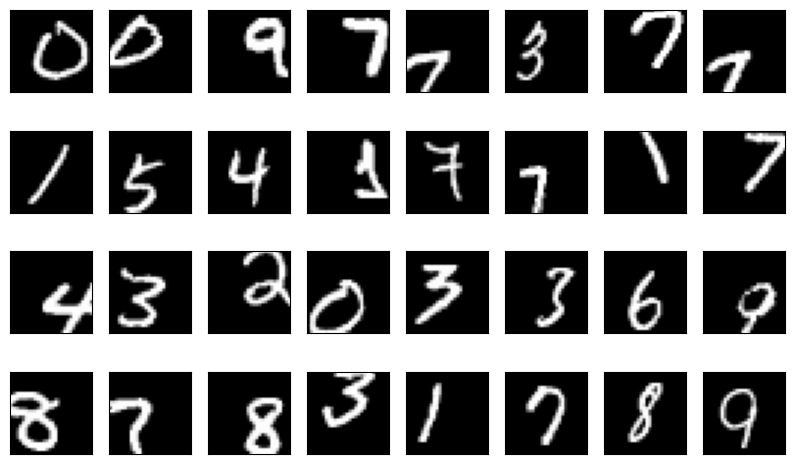

In [5]:
sh_samples = 50000 # Количество дополнительно сгенерированных образов для цифр (со смещениями)

sh_train_x = np.zeros((sh_samples, 28, 28, 1), dtype=np.float32)
sh_train_y = np.zeros((sh_samples,), dtype=np.int32)

src_idxs = random.sample(range(train_x.shape[0]), sh_samples)

sh = train_x.shape[1]
sw = train_x.shape[2]
for i in range(sh_samples):
    dh = random.randint(0, sh//4) * random.choice([-1, 1])
    dw = random.randint(0, sw//4) * random.choice([-1, 1])

    sample = train_x[src_idxs[i], ...]

    sh_train_x[i, max(-dh,0):min(sh-dh,sh), max(-dw,0):min(sw-dw, sw), :] = \
        sample[max( dh,0):min(sh+dh,sh), max( dw,0):min(sw+dw, sw), :]
    sh_train_y[i] = train_y[src_idxs[i]]

plot_some_samples(sh_train_x[:32, ...])

### Объединение исходного датасета MNSIT и двух новых сгенерированных
Получаем финальные train и test датасеты, содержащие исходные и новые сгенерированные данные (конкатенируем всё по нулевому измерению)

In [6]:
train_x = np.concatenate((train_x, bg_train_x, sh_train_x), axis=0)
train_y = np.concatenate((train_y, bg_train_y, sh_train_y), axis=0)

# Обучение классификатора

Для начала нам необходимо обучить обычный классификатор для распознавания цифр, но на нашем новом аугментированном датасете с классом "фон". Далее мы будем сконвертируем этот классификатор в FCN и применим для задачи слабой локализации.

### Параметры обучения

In [7]:
NUM_CLASSES = 11
NUM_EPOCHS = 3
BATCH_SIZE = 64

### Классификационная модель
Это наш классификатор на основе CNN. На выходе 11 классов.

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same'),
    tf.keras.layers.Conv2D(128, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
])

In [45]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,597,219 (21.35 MB)

 Trainable params: 1,865,739 (7.12 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,731,480 (14.23 MB)

### Подготовка модели к обучению

In [9]:
loss = tf.keras.losses.SparseCategoricalCrossentropy()
model.compile(optimizer='adam', loss=loss, metrics=['accuracy'])

### Обучение модели

In [10]:
model.fit(train_x, train_y, epochs=NUM_EPOCHS, batch_size=BATCH_SIZE)

Epoch 1/3
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9353 - loss: 0.2125
Epoch 2/3
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.9882 - loss: 0.0375
Epoch 3/3
3282/3282 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - accuracy: 0.9917 - loss: 0.0252


### Оценка качества классификационной модели

In [11]:
model.evaluate(test_x, test_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9927 - loss: 0.0275


[0.022940827533602715, 0.9937999844551086]

# Слабая локализация с помощью FCN
Теперь у нас есть обученный классификатор. Нам лишь остаётся конвертировать его в FCN  и применить эту FCN для задачи локализации -- получить тепловые карты в один проход.

Конвертация в FCN будет происходить в два этапа: сначала мы создадим целевую архитектуру FCN со случайными параметрами (весами), а затем скопируем соответствующие параметры (веса) из классификатора в FCN.

### Получение входного изображения для локализации

Можно сгенерировать случайное изображение с несколькими случайными цифрами из тестового множества

А можно загрузить готовое изображение digits.png

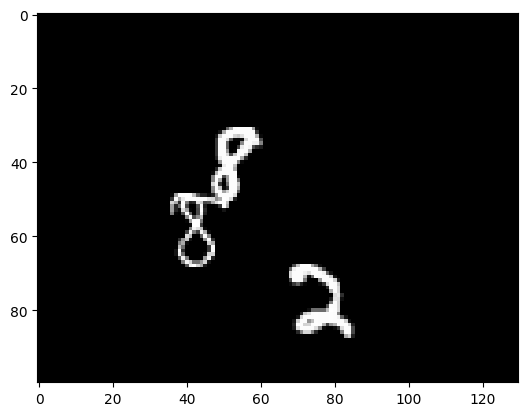

In [13]:
if True: # Сгенерировать случайное изображение

    img = np.zeros((100, 130, 1), dtype=np.float32)
    def add_digit(img, digit):
        ofs = (random.randint(0, img.shape[0]-digit.shape[0]),
               random.randint(0, img.shape[1]-digit.shape[1]))
        img[ofs[0]:ofs[0]+digit.shape[0], ofs[1]:ofs[1]+digit.shape[1], :] += digit
        img = np.clip(img, 0.0, 1.0)
        return img
    for _ in range(3):
        digit = test_x[random.randint(0, test_x.shape[0])]
        img = add_digit(img, digit)

else: # Загрузить готовое изображение 'digits.png'

    INPUT_IMAGE_FPTAH = 'digits.png'
    img = imageio.imread(INPUT_IMAGE_FPTAH, pilmode="RGB")
    img = img.astype(np.float32)/255.
    img = np.mean(img, axis=2, keepdims=True)

# Превращение входной картинки в RGB
# (для визуалзации и последующего смешивания с цветной тепловой картой)
img_clr = np.tile(img, (1, 1, 3))
_=plt.imshow(img_clr)

### Создание FCN модели
Создадим модель FCN. Она очень похожа на классификационную модель, но все полносвязные слои здесь заменены на свёрточные. Все кроме первого Dense слоя заменены на свёртки 1x1 (в нашем случае это лишь последний слой, так как их всего два). А первый Dense слой заменён на свёртку 7x7

**[ЗАДАНИЕ 1]** Вопрос: почему первый Dense слой мы заменили на свёртку 7x7, а не 1x1?

Далее мы будем копировать в эту FCN модель параметры (веса) из обученной классификационной модели.
Для того, чтобы в такой keras модели инициализировались слои (куда мы будем что-то копировать), нужно выполнить метод `build(shape)`. `shape` - желаемый размер входного тензора в нейросеть. `None` означает, что батч-сайз и пространственные размеры могут быть произвольными (ведь слои в нашей FCN никак не зависят от размера входа), а вот количество каналов (1) важно, так как оно участвует в определении размеров параметров первого свёрточного слоя в модели.

In [15]:
model_fcn = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same'),
    tf.keras.layers.Conv2D(128, (5, 5), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same'),
    tf.keras.layers.Conv2D(256, (7, 7), activation='relu', padding='valid'),
    tf.keras.layers.Conv2D(NUM_CLASSES, (1, 1), activation='softmax', padding='valid'),
])

model_fcn.build((None, None, None, 1))
#ответ на задание 1: чтобы не вычислять размер тепловой карты

In [46]:
model_fcn.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, None, None, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, None, None, 32) │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, None, None, 64) │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, None, None,     │       204,928 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, None, None,     │     1,605,888 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, None, None, 11) │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,865,739 (7.12 MB)

 Trainable params: 1,865,739 (7.12 MB)

 Non-trainable params: 0 (0.00 B)

### Список слоёв исходной модели
Для того, чтобы скопировать параметры классификационной сети в FCN сеть, нужно посмотреть, где эти параметры находятся (как до них добраться). Для этого распечатаем список слоёв исходной и новой модели.

In [16]:
for idx, layer in enumerate(model.layers):
    print('{} ==> {}'.format(idx, layer))

0 ==> <Conv2D name=conv2d, built=True>
1 ==> <Conv2D name=conv2d_1, built=True>
2 ==> <MaxPooling2D name=max_pooling2d, built=True>
3 ==> <Conv2D name=conv2d_2, built=True>
4 ==> <MaxPooling2D name=max_pooling2d_1, built=True>
5 ==> <Flatten name=flatten, built=True>
6 ==> <Dense name=dense, built=True>
7 ==> <Dense name=dense_1, built=True>


### Список слоёв новой FCN модели

In [17]:
for idx, layer in enumerate(model_fcn.layers):
    print('{} ==> {}'.format(idx, layer))

0 ==> <Conv2D name=conv2d_8, built=True>
1 ==> <Conv2D name=conv2d_9, built=True>
2 ==> <MaxPooling2D name=max_pooling2d_4, built=True>
3 ==> <Conv2D name=conv2d_10, built=True>
4 ==> <MaxPooling2D name=max_pooling2d_5, built=True>
5 ==> <Conv2D name=conv2d_11, built=True>
6 ==> <Conv2D name=conv2d_12, built=True>


### Копирование параметров из исходной модели
Нас интересуют только полносвязные и свёрточные слои, так как только у них есть обучаемые параметры.
У каждого такого слоя есть тензоры `kernel` и `bias`, которые означают веса и биас соответственно. В случае полносвязного слоя веса это матрица, а в случае свёрточного - четырёхмерный тензор с ядрами свёрток.

Первые два свёрточных слоя копируем как есть, без изменений.

А вот для двух полносвязных слоёв нужно применить reshape, чтобы скопировать веса из них в новые свёрточные слои.

**[ЗАДАНИЕ 2]** Вопрос: почему вызовы `reshape` имеют такие параметры `(7, 7, 64, 256)` и `(1, 1, 256, 11)` ?

In [19]:
#ответ: Dense(256) с входом 6272
# Каждый из 256 нейронов имеет 6272 весовых коэффициента

# Conv2D 7×7 с 128 входными каналами
# Каждое из 256 ядер 7×7 имеет: 7×7×128 = 6272 параметров

# Исходное: Dense(11) с kernel.shape = (256, 11)
# Целевое: Conv2D(11, 1×1) с kernel.shape = (1, 1, 256, 11)

# Почему 1×1?
# Потому что это "точечная свёртка", эквивалентная Dense
# Каждый нейрон смотрит на все 256 каналов, но только в одной точке

model_fcn.layers[0].kernel = model.layers[0].kernel
model_fcn.layers[0].bias = model.layers[0].bias
model_fcn.layers[1].kernel = model.layers[1].kernel
model_fcn.layers[1].bias = model.layers[1].bias
model_fcn.layers[3].kernel = model.layers[3].kernel
model_fcn.layers[3].bias = model.layers[3].bias
model_fcn.layers[5].kernel = tf.reshape(model.layers[6].kernel, (7, 7, 64, 256))
model_fcn.layers[5].bias = model.layers[6].bias
model_fcn.layers[6].kernel = tf.reshape(model.layers[7].kernel, (1, 1, 256, 11))
model_fcn.layers[6].bias = model.layers[7].bias

ValueError: You cannot add new elements of state (variables or sub-layers) to a layer that is already built. All state must be created in the `__init__()` method or in the `build()` method.

In [30]:
inputs = tf.keras.Input(shape=(None, None, 1))

# Последовательно добавляем слои
x = tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
x = tf.keras.layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(128, (5, 5), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(256, (7, 7), activation='relu', padding='valid')(x)
outputs = tf.keras.layers.Conv2D(11, (1, 1), activation='softmax', padding='valid')(x)

model_fcn = tf.keras.Model(inputs=inputs, outputs=outputs)

# Теперь можно установить веса
model_fcn.layers[1].set_weights(model.layers[0].get_weights())  # conv2d
model_fcn.layers[2].set_weights(model.layers[1].get_weights())  # conv2d_1
model_fcn.layers[4].set_weights(model.layers[3].get_weights())  # conv2d_2

In [34]:
# Проверьте размерности
print("Проверка размеров:")
print(f"model.layers[6].kernel.shape = {model.layers[6].kernel.shape}")
print(f"model.layers[7].kernel.shape = {model.layers[7].kernel.shape}")

Проверка размеров:
model.layers[6].kernel.shape = (6272, 256)
model.layers[7].kernel.shape = (256, 11)


In [35]:
# 1. СОЗДАНИЕ FCN МОДЕЛИ
inputs = tf.keras.Input(shape=(None, None, 1))
x = tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
x = tf.keras.layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(128, (5, 5), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(256, (7, 7), activation='relu', padding='valid')(x)
outputs = tf.keras.layers.Conv2D(11, (1, 1), activation='softmax', padding='valid')(x)
model_fcn = tf.keras.Model(inputs=inputs, outputs=outputs)


In [48]:
# 2. ДИАГНОСТИКА РАЗМЕРОВ
print("ДИАГНОСТИКА")
print("Размеры весов в исходной модели:")
for i, layer in enumerate(model.layers):
    if hasattr(layer, 'kernel'):
        print(f"  Слой {i} ({layer.name}): kernel.shape = {layer.kernel.shape}")

# Особенно важны Dense слои:
print(f"\nПервый Dense слой (индекс 6):")
print(f"  kernel.shape = {model.layers[6].kernel.shape}")
print(f"  bias.shape = {model.layers[6].bias.shape}")


ДИАГНОСТИКА
Размеры весов в исходной модели:
  Слой 0 (conv2d): kernel.shape = (5, 5, 1, 32)
  Слой 1 (conv2d_1): kernel.shape = (5, 5, 32, 64)
  Слой 3 (conv2d_2): kernel.shape = (5, 5, 64, 128)
  Слой 6 (dense): kernel.shape = (6272, 256)
  Слой 7 (dense_1): kernel.shape = (256, 11)

Первый Dense слой (индекс 6):
  kernel.shape = (6272, 256)
  bias.shape = (256,)


In [37]:
# 3. ВЫЧИСЛЯЕМ ПРАВИЛЬНЫЕ РАЗМЕРЫ ДЛЯ RESHAPE
# Размер kernel первого Dense слоя: (input_dim, 256)
dense1_kernel_shape = model.layers[6].kernel.shape  # Например: (3136, 256)
dense1_input_dim = dense1_kernel_shape[0]  # 3136

# Нужно разложить 3136 на 7×7×X
# 3136 = 7 × 7 × 64
# 1605632 = ? × ? × ? (ваш случай)
print(f"\nФакторизация {dense1_input_dim}:")
# Пробуем найти подходящие размеры
import math
possible_factors = []
for i in range(1, int(math.sqrt(dense1_input_dim)) + 1):
    if dense1_input_dim % i == 0:
        possible_factors.append((i, dense1_input_dim // i))

print(f"Возможные разложения: {possible_factors[:10]}...")


Факторизация 6272:
Возможные разложения: [(1, 6272), (2, 3136), (4, 1568), (7, 896), (8, 784), (14, 448), (16, 392), (28, 224), (32, 196), (49, 128)]...


In [50]:
# 4. ПРАВИЛЬНЫЙ RESHAPE (с вычислением размеров)
try:
    # Автоматически находим правильные размеры
    # Ваш kernel имеет размер 1605632 = 56 × 56 × 512?
    # Давайте вычислим:
    total_elements = tf.size(model.layers[6].kernel).numpy()
    print(f"\nВсего элементов в kernel: {total_elements}")

    # Стандартные размеры для MNIST после 2 MaxPool:
    # 28×28 → 14×14 → 7×7
    # Если у вас другая архитектура, размеры будут другими!

    # ПРОБУЕМ РАЗНЫЕ ВАРИАНТЫ:
    # Вариант A: 7×7×64×256 = 7×7×16384 = 802816 (не подходит)
    # Вариант B: 14×14×64×256 = 14×14×16384 = 3211264 (не подходит)
    # Вариант C: 7×7×128×256 = 7×7×32768 = 1605632 ✓ ВАШ СЛУЧАЙ!

    if total_elements == 1605632:
        print("Обнаружен размер 1605632 = 7×7×128×256")
        reshaped_kernel1 = tf.reshape(model.layers[6].kernel, (7, 7, 128, 256))
    elif total_elements == 802816:
        print("Обнаружен размер 802816 = 7×7×64×256")
        reshaped_kernel1 = tf.reshape(model.layers[6].kernel, (7, 7, 64, 256))
    else:
        print(f"Неизвестный размер {total_elements}")
        # Вручную подберите размеры
        height = 7  # или 14, или другой
        width = 7   # или 14, или другой
        input_channels = 128  # ИЗМЕНИТЕ НА ОСНОВЕ ВАШЕЙ АРХИТЕКТУРЫ
        output_channels = 256

        reshaped_kernel1 = tf.reshape(model.layers[6].kernel,
                                     (height, width, input_channels, output_channels))

    # 5. ПЕРЕНОС ВЕСОВ (с правильными размерами)
    # Conv слои (как в вашем коде)
    model_fcn.layers[1].set_weights(model.layers[0].get_weights())  # conv2d
    model_fcn.layers[2].set_weights(model.layers[1].get_weights())  # conv2d_1
    model_fcn.layers[4].set_weights(model.layers[3].get_weights())  # conv2d_2

    # Dense - Conv (с правильными размерами)
    model_fcn.layers[5].set_weights([reshaped_kernel1.numpy(),
                                     model.layers[6].bias.numpy()])

    # Второй Dense - Conv2D 1×1
    dense2_kernel = model.layers[7].kernel
    # Размер должен быть (256, 11) → (1, 1, 256, 11)
    if dense2_kernel.shape == (256, 11):
        reshaped_kernel2 = tf.reshape(dense2_kernel, (1, 1, 256, 11))
        model_fcn.layers[6].set_weights([reshaped_kernel2.numpy(),
                                         model.layers[7].bias.numpy()])
        print("Все веса успешно перенесены!")
    else:
        print(f"Второй Dense имеет неожиданный размер: {dense2_kernel.shape}")

except Exception as e:
    print(f"Ошибка: {e}")
    print("\nСкорее всего, архитектура отличается от стандартной.")
    print("Проверить фактические размеры слоёв:")

    # Автоматический подбор размеров
    dense1_kernel = model.layers[6].kernel.numpy()
    total = dense1_kernel.size  # 1605632 в вашем случае

    print(f"\nАвтоматический подбор для {total} элементов:")
    # Ищем разложение total = h × w × in_c × out_c
    # где out_c = 256 (из Dense(256))
    out_c = 256
    remaining = total // out_c  # 1605632 / 256 = 6272

    print(f"Оставшиеся элементы на h×w×in_c: {remaining}")

    # Попробуем найти целочисленное разложение
    for h in [7, 14, 28]:
        for w in [7, 14, 28]:
            if h * w <= remaining and remaining % (h * w) == 0:
                in_c = remaining // (h * w)
                print(f"  Возможно: ({h}, {w}, {in_c}, {out_c})")
                print(f"    Проверка: {h}×{w}×{in_c}×{out_c} = {h*w*in_c*out_c}")


Всего элементов в kernel: 1605632
Обнаружен размер 1605632 = 7×7×128×256
Ошибка: You called `set_weights(weights)` on layer 'max_pooling2d_13' with a weight list of length 2, but the layer was expecting 0 weights.

Скорее всего, архитектура отличается от стандартной.
Проверить фактические размеры слоёв:

Автоматический подбор для 1605632 элементов:
Оставшиеся элементы на h×w×in_c: 6272
  Возможно: (7, 7, 128, 256)
    Проверка: 7×7×128×256 = 1605632
  Возможно: (7, 14, 64, 256)
    Проверка: 7×14×64×256 = 1605632
  Возможно: (7, 28, 32, 256)
    Проверка: 7×28×32×256 = 1605632
  Возможно: (14, 7, 64, 256)
    Проверка: 14×7×64×256 = 1605632
  Возможно: (14, 14, 32, 256)
    Проверка: 14×14×32×256 = 1605632
  Возможно: (14, 28, 16, 256)
    Проверка: 14×28×16×256 = 1605632
  Возможно: (28, 7, 32, 256)
    Проверка: 28×7×32×256 = 1605632
  Возможно: (28, 14, 16, 256)
    Проверка: 28×14×16×256 = 1605632
  Возможно: (28, 28, 8, 256)
    Проверка: 28×28×8×256 = 1605632


In [51]:
import numpy as np

# 1. СОЗДАЁМ FCN МОДЕЛЬ
inputs = tf.keras.Input(shape=(None, None, 1))
x = tf.keras.layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
x = tf.keras.layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(128, (5, 5), activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D((2, 2), (2, 2), padding='same')(x)
x = tf.keras.layers.Conv2D(256, (7, 7), activation='relu', padding='valid')(x)
outputs = tf.keras.layers.Conv2D(11, (1, 1), activation='softmax', padding='valid')(x)
model_fcn = tf.keras.Model(inputs=inputs, outputs=outputs)

# 2. ПЕРЕНОС ВЕСОВ С ПРАВИЛЬНЫМИ ИНДЕКСАМИ
print("Перенос весов с правильными индексами:")

# Сначала выведем индексы всех слоёв FCN
print("\nСлои FCN модели:")
for i, layer in enumerate(model_fcn.layers):
    print(f"  {i}: {layer.name} ({layer.__class__.__name__})")

# Правильные индексы для свёрточных слоёв:
# FCN[1] = Conv2D(32) - соответствует CNN[0]
# FCN[2] = Conv2D(64) - соответствует CNN[1]
# FCN[4] = Conv2D(128) - соответствует CNN[3]
# FCN[6] = Conv2D(256) - соответствует CNN[6] (Dense→Conv)
# FCN[7] = Conv2D(11) - соответствует CNN[7] (Dense→Conv)

# 3. ПЕРЕНАПРАВЛЯЕМ ВЕСА В ПРАВИЛЬНЫЕ СЛОИ
# Conv слои (одинаковые в CNN и FCN)
model_fcn.layers[1].set_weights(model.layers[0].get_weights())  # conv2d
print(f"  Перенесены веса: CNN[0] - FCN[1]")

model_fcn.layers[2].set_weights(model.layers[1].get_weights())  # conv2d_1
print(f"  Перенесены веса: CNN[1] - FCN[2]")

model_fcn.layers[4].set_weights(model.layers[3].get_weights())  # conv2d_2
print(f"  Перенесены веса: CNN[3] - FCN[4]")

# 4. Dense - Conv слои (с reshape)
# Первый Dense(256) - Conv2D 7×7
# kernel.shape = (6272, 256) = 7×7×128×256
dense1_weights = model.layers[6].get_weights()
reshaped_kernel1 = np.reshape(dense1_weights[0], (7, 7, 128, 256))
model_fcn.layers[6].set_weights([reshaped_kernel1, dense1_weights[1]])
print(f"  Перенесены веса: CNN[6] (Dense) - FCN[6] (Conv2D 7×7)")
print(f"  Reshape: (6272, 256) - (7, 7, 128, 256)")

# Второй Dense(11) - Conv2D 1×1
dense2_weights = model.layers[7].get_weights()
reshaped_kernel2 = np.reshape(dense2_weights[0], (1, 1, 256, 11))
model_fcn.layers[7].set_weights([reshaped_kernel2, dense2_weights[1]])
print(f"  Перенесены веса: CNN[7] (Dense) → FCN[7] (Conv2D 1×1)")
print(f"  Reshape: (256, 11) - (1, 1, 256, 11)")

print("\nВсе веса успешно перенесены!")

Перенос весов с правильными индексами:

Слои FCN модели:
  0: input_layer_7 (InputLayer)
  1: conv2d_33 (Conv2D)
  2: conv2d_34 (Conv2D)
  3: max_pooling2d_14 (MaxPooling2D)
  4: conv2d_35 (Conv2D)
  5: max_pooling2d_15 (MaxPooling2D)
  6: conv2d_36 (Conv2D)
  7: conv2d_37 (Conv2D)
  Перенесены веса: CNN[0] - FCN[1]
  Перенесены веса: CNN[1] - FCN[2]
  Перенесены веса: CNN[3] - FCN[4]
  Перенесены веса: CNN[6] (Dense) - FCN[6] (Conv2D 7×7)
  Reshape: (6272, 256) - (7, 7, 128, 256)
  Перенесены веса: CNN[7] (Dense) → FCN[7] (Conv2D 1×1)
  Reshape: (256, 11) - (1, 1, 256, 11)

Все веса успешно перенесены!


In [47]:
model_fcn.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, None, None, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, None, None, 32) │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, None, None, 64) │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, None, None, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, None, None,     │       204,928 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, None, None,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, None, None,     │     1,605,888 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, None, None, 11) │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,865,739 (7.12 MB)

 Trainable params: 1,865,739 (7.12 MB)

 Non-trainable params: 0 (0.00 B)

### Запуск FCN для входной картинки и получение тепловых карт

Теперь наша FCN модель готова к слабой локализации. На вход можно сразу подавать входное изображение (не забыв приклеить дополнительное измерение для батча `img[None, ...]`)
Предсказание делается в один проход, что должно быть существенно быстрее метода скользящего окна.

**[ЗАДАНИЕ 3]** Реализуйте получение тепловых карт (трёхмерный тензор `heatmaps`) с использованием FCN в одну строчку. Используйте магическую команду `%%time` для измерения времени работы такого подхода. Сравните время работы с временем работы скользящего окна из предыдущего практического урока.

In [41]:
%%time
heatmaps = heatmaps = model_fcn.predict(img[None, ...], verbose=0)[0]

CPU times: user 383 ms, sys: 4.41 ms, total: 387 ms
Wall time: 421 ms


### Расширение тепловых карт
Теперь нам понадобится сделать расширение тепловых карт до размеров исходной картинки.

Так как мы использовали пулинги, выходные тепловые карты получились в низком разрешении, поэтому сначала надо сделать upscale (resize) до размера исходной картинки, но с учётом рецептивного поля нейросети.

Далее сделаем финальный паддинг до размера исходной картинки.

In [43]:
from skimage.transform import resize

rec_field = (28, 28) # рецептивное поле FCN модели

# Сначала масштабируем тепловые карты
heatmaps = resize(heatmaps, (
        img.shape[0]-rec_field[0]+1,
        img.shape[1]-rec_field[1]+1),
    order=3, mode='reflect', anti_aliasing=True)

# Потом делаем паддинг
diff = (img.shape[0]-heatmaps.shape[0],
        img.shape[1]-heatmaps.shape[1],)
heatmaps = np.pad(heatmaps, (
    (diff[0]//2,diff[0]-diff[0]//2),
    (diff[1]//2,diff[1]-diff[1]//2),
    (0, 0)
), 'constant')

### Визуализация тепловых карт для разных классов
Визуализируем тепловые карты, соответствующие разным классам, наложенные на исходное изображение

Heatmap for class: 0


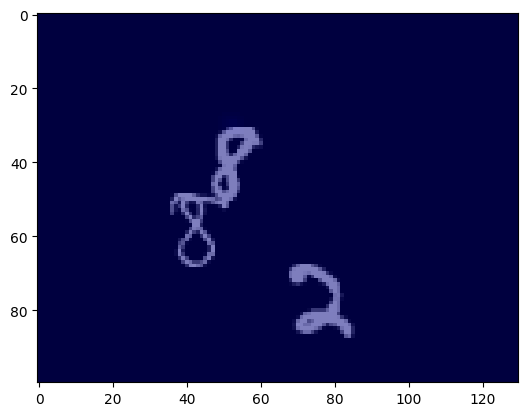

Heatmap for class: 1


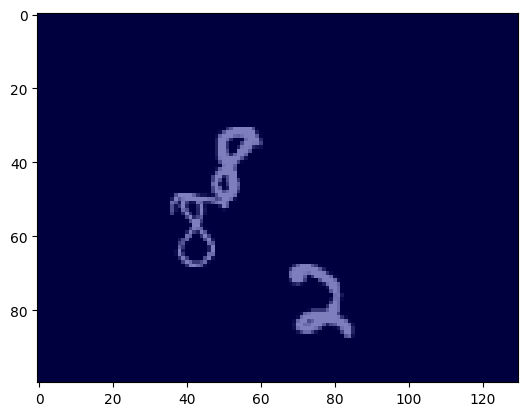

Heatmap for class: 2


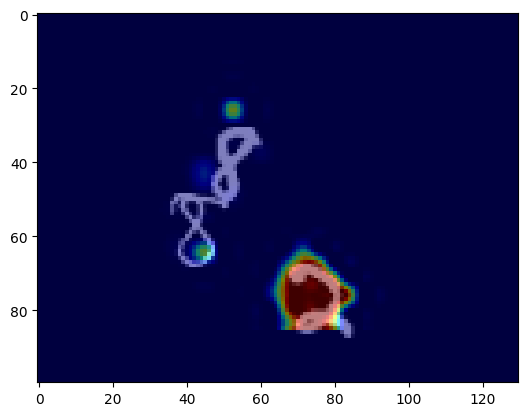

Heatmap for class: 3


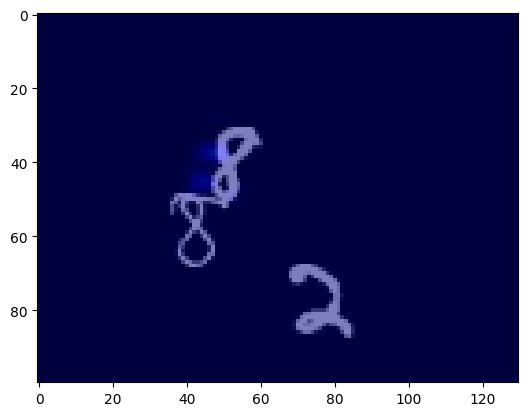

Heatmap for class: 4


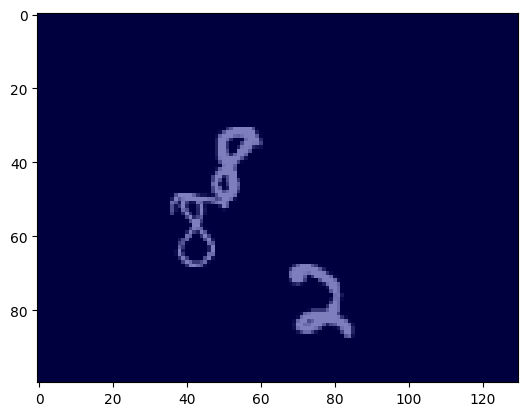

Heatmap for class: 5


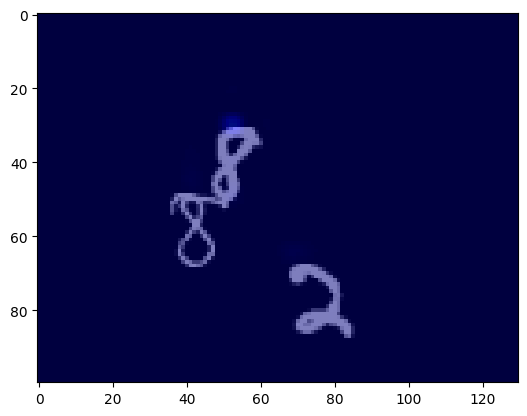

Heatmap for class: 6


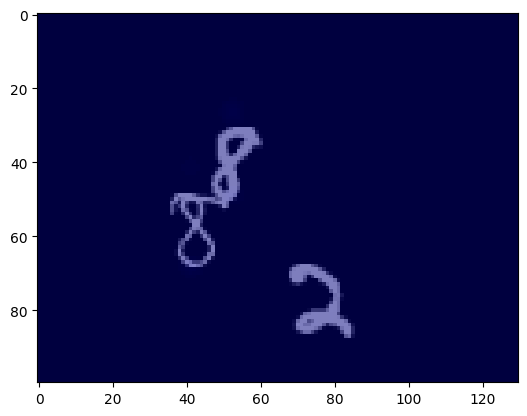

Heatmap for class: 7


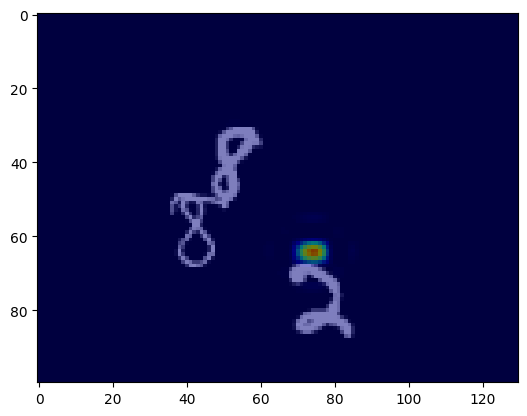

Heatmap for class: 8


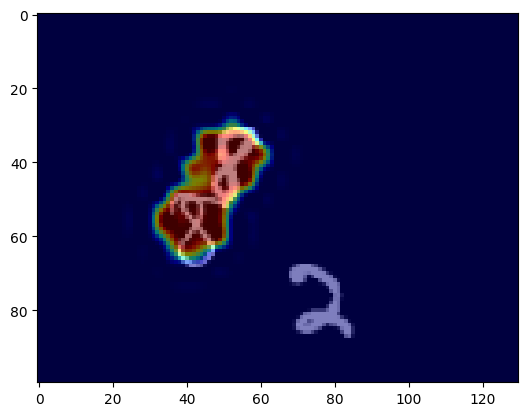

Heatmap for class: 9


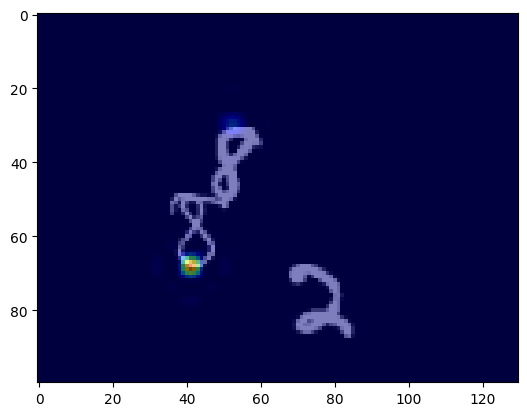

Heatmap for class: 10


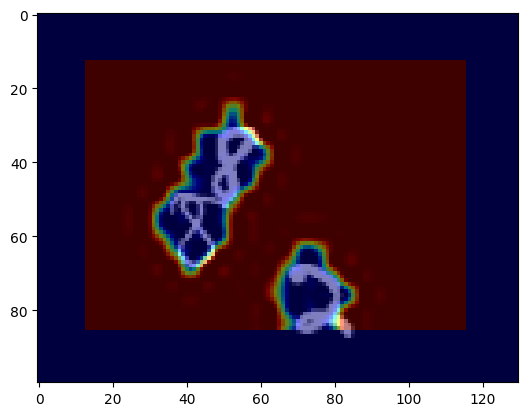

In [44]:
for clss in range(11):
    heatmap = heatmaps[..., clss]
    heatmap_clr = plt.get_cmap('jet')(heatmap)[..., :3]
    print('Heatmap for class:', clss)
    plt.imshow(img_clr*0.5 + heatmap_clr*0.5)
    plt.show()